
Figures generated for activations: tanh, heaviside, rect
Modify the list `activations_to_plot` to control which are drawn.
Activation definitions:
  tanh: standard hyperbolic tangent
  heaviside: H(z)=1 if z>=0 else 0
  rect: rectangular pulse centered at 0 with half-width 0.5 (change in act_rect)



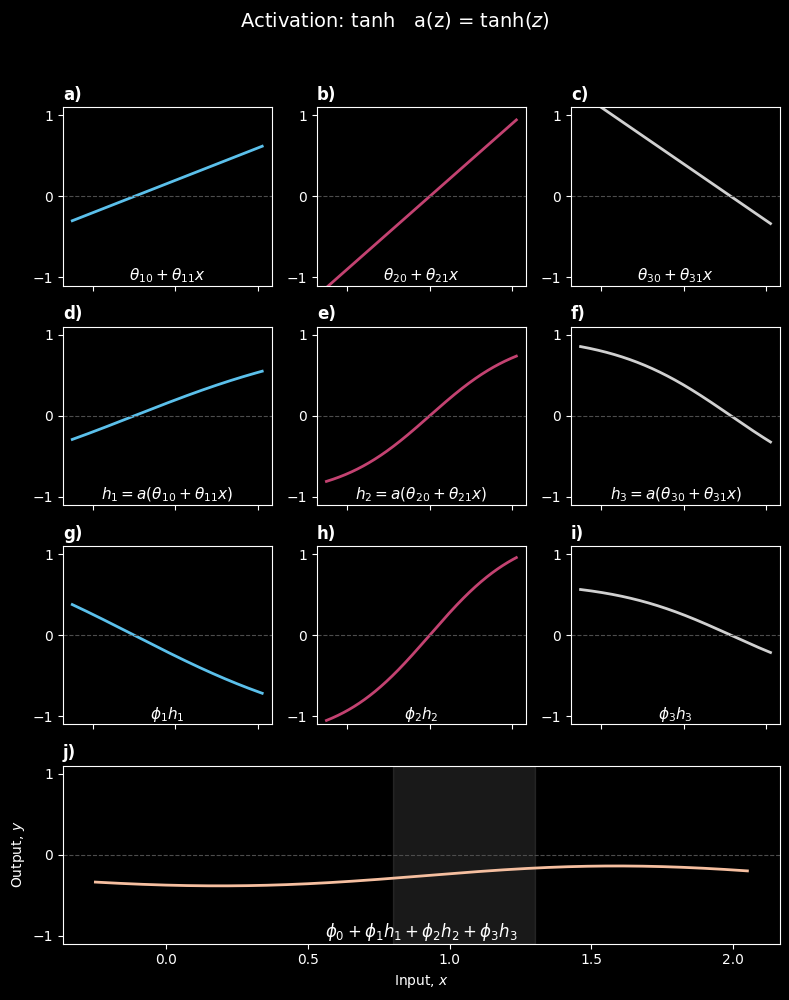

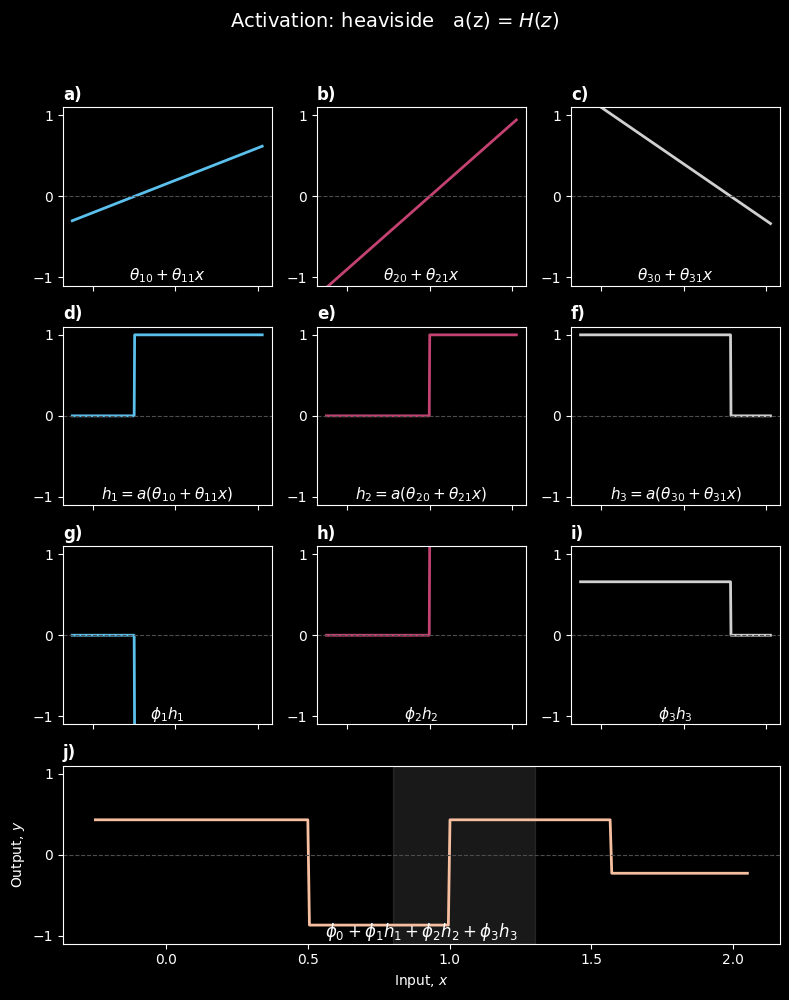

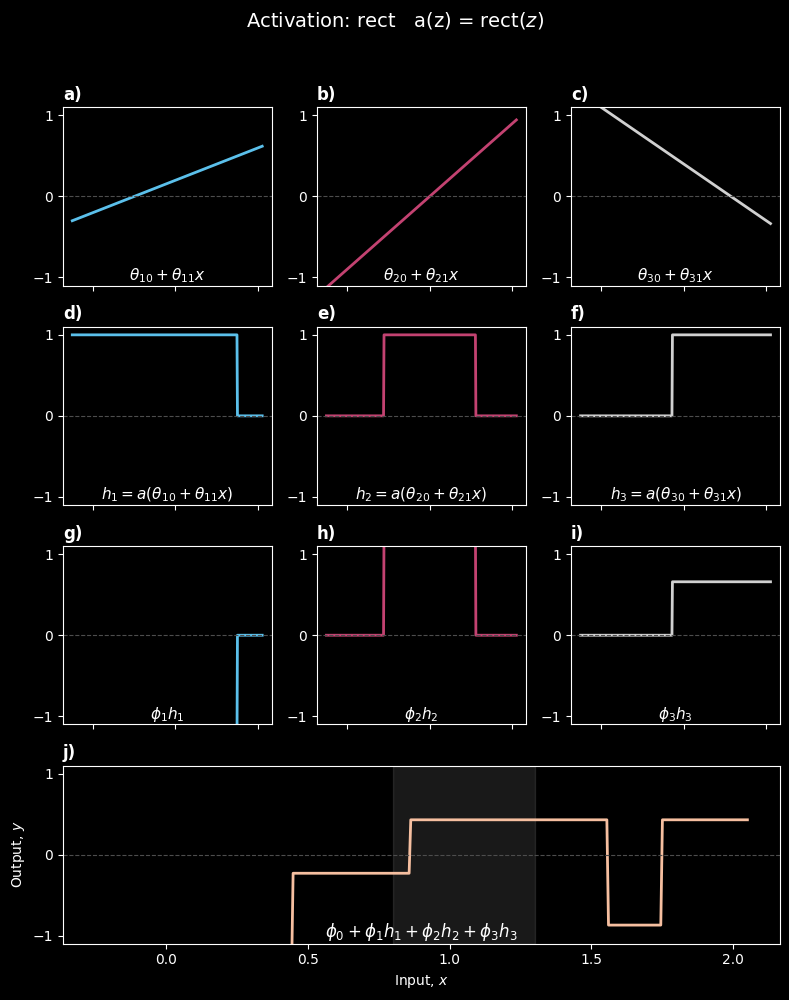

In [3]:
# Redraw network decomposition figure with selectable activation functions
# Parameters (given)
import numpy as np
import matplotlib.pyplot as plt
from textwrap import dedent

plt.style.use('dark_background')  # dark background similar to original

# Network parameters
phi0, phi1, phi2, phi3, th10, th11, th20, th21, th30, th31 = (
    -0.23, -1.3, 1.3, 0.66, -0.2, 0.4, -0.9, 0.9, 1.1, -0.7
)

params = {
    'phi0': phi0,
    'phi': np.array([phi1, phi2, phi3]),
    'theta': np.array([[th10, th11], [th20, th21], [th30, th31]])
}

# Activation function definitions
def act_tanh(z):
    return np.tanh(z)

def act_heaviside(z):
    return (z >= 0).astype(float)

def act_rect(z, center=0.0, half_width=0.5):
    # Rectangular pulse: 1 inside [center-half_width, center+half_width], else 0
    return ((z >= center - half_width) & (z <= center + half_width)).astype(float)

activation_bank = {
    'tanh': (act_tanh, r'$\tanh(z)$'),
    'heaviside': (act_heaviside, r'$H(z)$'),
    'rect': (act_rect, r'$\operatorname{rect}(z)$')
}

# Choose which activation(s) to plot
activations_to_plot = ['tanh', 'heaviside', 'rect']  # modify list to restrict

x = np.linspace(-0.25, 2.05, 400)
colors = ['#5bc0eb', '#c34271', '#d0d0d0']  # base colors for units
letters = list('abcdefghi') + ['j']

from itertools import count
letter_counter = count()

def panel_label(ax):
    idx = next(letter_counter)
    ax.text(0.0, 1.02, f"{letters[idx]})", transform=ax.transAxes, ha='left', va='bottom', fontsize=12, fontweight='bold')


def plot_for_activation(name):
    global letter_counter
    letter_counter = count()  # reset panel lettering

    act_fn, act_label = activation_bank[name]
    theta = params['theta']
    phi = params['phi']

    # Pre-activations (affine) for each hidden unit
    z = np.array([theta[i,0] + theta[i,1]*x for i in range(3)])  # shape (3, len(x))
    h = act_fn(z)

    # Weighted hidden outputs and final output
    weighted = phi[:, None] * h
    y = phi0 + weighted.sum(axis=0)

    fig, axes = plt.subplots(4, 3, figsize=(8, 10), sharex='col')
    fig.suptitle(f"Activation: {name}   a(z) = {act_label}", y=0.995, fontsize=14)

    # Row 1: affine pre-activations
    for i in range(3):
        ax = axes[0, i]
        ax.plot(x, z[i], color=colors[i], lw=2)
        ax.axhline(0, color='0.3', lw=0.8, ls='--')
        ax.set_ylim(-1.1, 1.1)
        ax.set_yticks([-1, 0, 1])
        panel_label(ax)
        ax.text(0.5, 0.03, fr"$\theta_{{{i+1}0}} + \theta_{{{i+1}1}} x$", transform=ax.transAxes, ha='center', fontsize=11)

    # Row 2: activations h_i
    for i in range(3):
        ax = axes[1, i]
        ax.plot(x, h[i], color=colors[i], lw=2)
        ax.axhline(0, color='0.3', lw=0.8, ls='--')
        ax.set_ylim(-1.1, 1.1)
        ax.set_yticks([-1, 0, 1])
        panel_label(ax)
        ax.text(0.5, 0.03, fr"$h_{i+1} = a(\theta_{{{i+1}0}} + \theta_{{{i+1}1}} x)$", transform=ax.transAxes, ha='center', fontsize=11)

    # Row 3: weighted hidden outputs phi_i h_i
    for i in range(3):
        ax = axes[2, i]
        ax.plot(x, weighted[i], color=colors[i], lw=2)
        ax.axhline(0, color='0.3', lw=0.8, ls='--')
        ax.set_ylim(-1.1, 1.1)
        ax.set_yticks([-1, 0, 1])
        panel_label(ax)
        ax.text(0.5, 0.03, fr"$\phi_{i+1} h_{i+1}$", transform=ax.transAxes, ha='center', fontsize=11)

    # Row 4: final output occupies all 3 columns
    for j in range(3):
        axes[3, j].remove()
    from matplotlib.gridspec import GridSpec
    gs = axes[3,0].get_gridspec()
    out_ax = fig.add_subplot(gs[3, :])
    out_ax.plot(x, y, color='#f6bfa0', lw=2)
    out_ax.axhline(0, color='0.3', lw=0.8, ls='--')
    out_ax.axvspan(0.8, 1.3, color='white', alpha=0.1)  # optional highlight
    out_ax.set_ylim(-1.1, 1.1)
    out_ax.set_yticks([-1, 0, 1])
    out_ax.set_xlabel('Input, $x$')
    out_ax.set_ylabel('Output, $y$')
    panel_label(out_ax)
    out_ax.text(0.5, 0.04, r"$\phi_0+\phi_1 h_1 + \phi_2 h_2 + \phi_3 h_3$", transform=out_ax.transAxes, ha='center', fontsize=12)

    plt.tight_layout(rect=(0,0,1,0.97))
    return fig

figures = [plot_for_activation(name) for name in activations_to_plot]
figures[-1]  # display last

print(dedent('''\nFigures generated for activations: {}\nModify the list `activations_to_plot` to control which are drawn.\nActivation definitions:\n  tanh: standard hyperbolic tangent\n  heaviside: H(z)=1 if z>=0 else 0\n  rect: rectangular pulse centered at 0 with half-width 0.5 (change in act_rect)\n'''.format(', '.join(activations_to_plot))))